<a href="https://colab.research.google.com/github/Zandersan/ml_study/blob/yolo_debinha_niko/YOLO_debinha_niko.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================
# 1. Preparação do ambiente
# ==============================================================

from google.colab import drive
drive.mount('/content/drive')

# Limpar qualquer coisa antiga
!rm -rf /content/sample_data /content/darknet /content/runs /content/data

# Instalar YOLOv8
!pip install ultralytics -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==============================================================
# 2. Extrair dataset do Drive
# ==============================================================

import zipfile, os, shutil, random

zip_path = "/content/drive/MyDrive/debinha_niko.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

base_dir = os.path.join(extract_path, "debinha_niko")
print("Arquivos extraídos:", os.listdir(base_dir))

Arquivos extraídos: ['obj.data', 'data', 'train.txt', 'obj_train_data', 'obj.names']


In [ ]:
# ==============================================================
# 3. Reorganizar dataset para YOLOv8
# ==============================================================

# Criar pastas no formato YOLO
yolo_base = os.path.join(base_dir, "yolo_format")
for split in ["train", "val"]:
    os.makedirs(os.path.join(yolo_base, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(yolo_base, split, "labels"), exist_ok=True)

# Listar imagens
images_dir = os.path.join(base_dir, "data")
labels_dir = os.path.join(base_dir, "obj_train_data")

all_images = [f for f in os.listdir(images_dir) if f.lower().endswith((".jpg",".jpeg",".png"))]
all_images.sort()

# Divisão 80/20 entre treino e validação
random.seed(42)
random.shuffle(all_images)
split_idx = int(0.8 * len(all_images))
train_imgs = all_images[:split_idx]
val_imgs   = all_images[split_idx:]

def move_files(img_list, split):
    for img_file in img_list:
        img_src = os.path.join(images_dir, img_file)
        label_src = os.path.join(labels_dir, os.path.splitext(img_file)[0] + ".txt")

        img_dst = os.path.join(yolo_base, split, "images", img_file)
        label_dst = os.path.join(yolo_base, split, "labels", os.path.splitext(img_file)[0] + ".txt")

        shutil.copy(img_src, img_dst)
        if os.path.exists(label_src):
            shutil.copy(label_src, label_dst)

move_files(train_imgs, "train")
move_files(val_imgs, "val")

print("Treino:", len(train_imgs), "Validação:", len(val_imgs))

Treino: 16 Validação: 5


In [ ]:
# ==============================================================
# 4. Criar data.yaml
# ==============================================================

import yaml

data_yaml = {
    'train': os.path.join(yolo_base, "train/images"),
    'val': os.path.join(yolo_base, "val/images"),
    'nc': 2,
    'names': ['Niko', 'Debinha']
}

with open(os.path.join(yolo_base, "data.yaml"), 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("Arquivo data.yaml criado com sucesso!")
print(data_yaml)

Arquivo data.yaml criado com sucesso!
{'train': '/content/data/debinha_niko/yolo_format/train/images', 'val': '/content/data/debinha_niko/yolo_format/val/images', 'nc': 2, 'names': ['Niko', 'Debinha']}


In [ ]:
# ==============================================================
# 5. Treinar YOLOv8
# ==============================================================

from ultralytics import YOLO

# Modelo base (nano para rapidez)
model = YOLO("yolov8n.pt")

model.train(
    data=os.path.join(yolo_base, "data.yaml"),
    epochs=50,
    batch=32,
    imgsz=640
)

Ultralytics 8.3.185 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/debinha_niko/yolo_format/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=

Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             


  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  8                  -1  1    460288  ultralytics.nn.modules.block.C2f             [256, 256, 1, True]           
  9                  -1  1    164608  ultralytics.nn.modules.block.SPPF            [256, 256, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  1    148224  ultralytics.nn.modules.block.C2f             [384, 128, 1]                 
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None

train: Scanning /content/data/debinha_niko/yolo_format/train/labels... 15 images, 1 backgrounds, 0 corrupt: 100%|██████████| 16/16 [00:00<00:00, 129.37it/s]

train: New cache created: /content/data/debinha_niko/yolo_format/train/labels.cache


...

                   all          5          5      0.715      0.167      0.259       0.18



50 epochs completed in 0.216 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.185 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:01<00:00,  1.15s/it]


                   all          5          5    0.00332          1      0.601      0.442
                  Niko          3          3    0.00394          1      0.995      0.797
               Debinha          2          2    0.00271          1      0.207     0.0871
Speed: 1.9ms preprocess, 180.5ms inference, 0.0ms loss, 21.4ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f9f88bb46e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
# ==============================================================
# 6. Avaliar
# ==============================================================

model.val()

Ultralytics 8.3.185 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2129.6±491.4 MB/s, size: 203.6 KB)


val: Scanning /content/data/debinha_niko/yolo_format/val/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5/5 [00:00<?, ?it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:01<00:00,  1.15s/it]


                   all          5          5    0.00332          1      0.601      0.442
                  Niko          3          3    0.00394          1      0.995      0.797
               Debinha          2          2    0.00271          1      0.207     0.0871
Speed: 1.5ms preprocess, 179.4ms inference, 0.0ms loss, 21.4ms postprocess per image
Results saved to runs/detect/train2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f9f8516cec0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804


image 1/1 /content/data/debinha_niko/yolo_format/val/images/007.jpeg: 640x384 (no detections), 157.1ms
Speed: 4.6ms preprocess, 157.1ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 384)


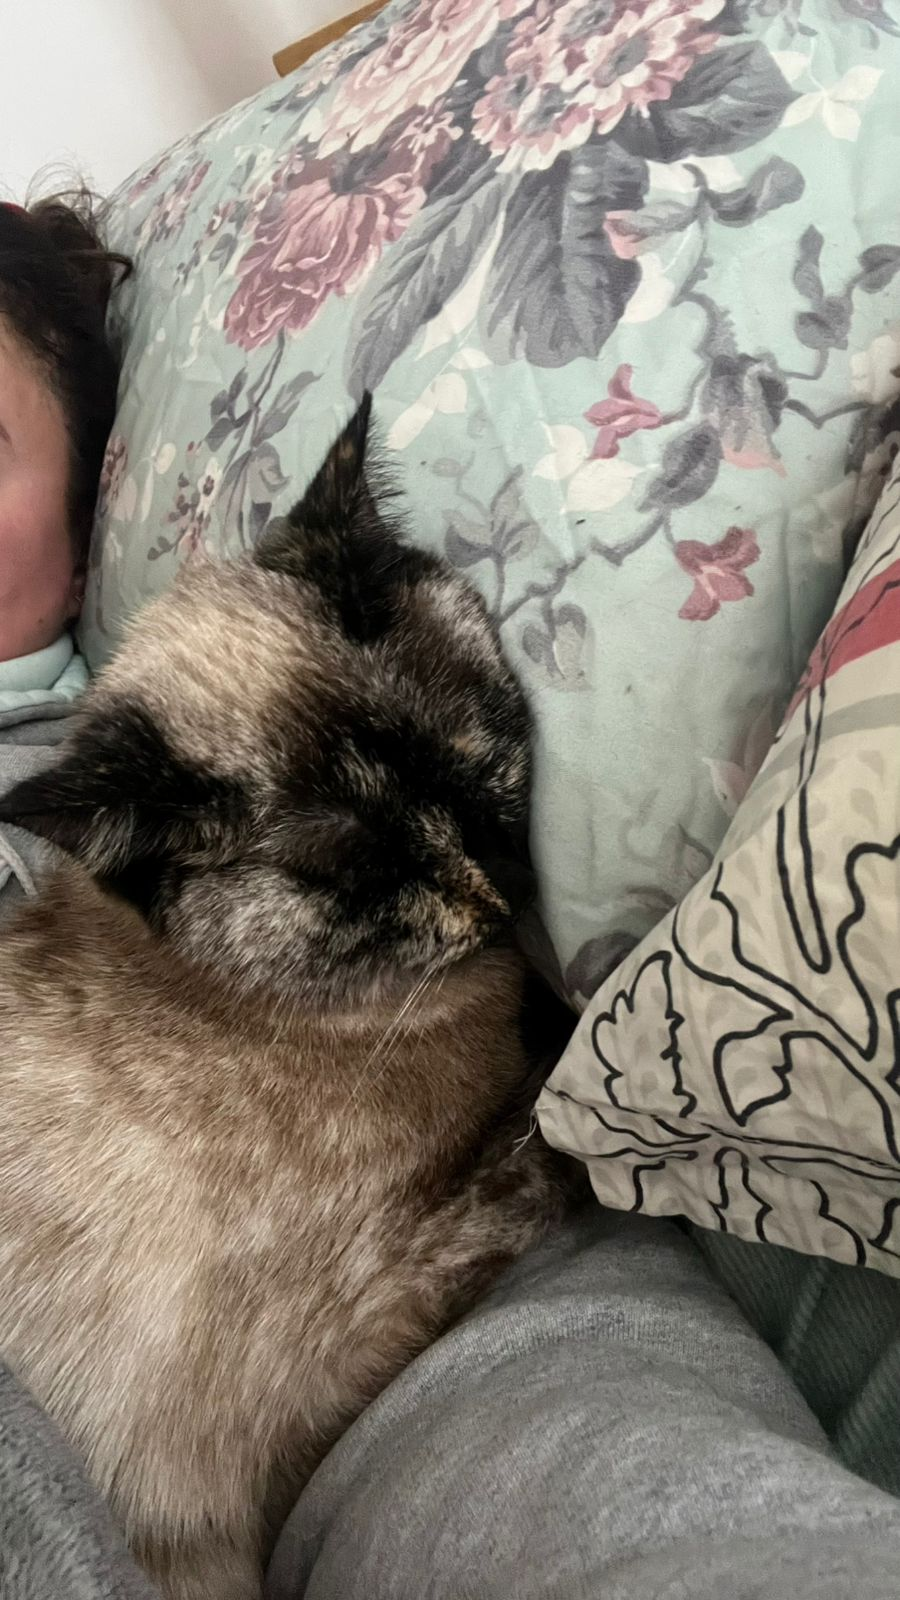

In [ ]:
# ==============================================================
# 7. Testar inferência em uma imagem
# ==============================================================

test_img = os.path.join(yolo_base, "val/images", val_imgs[0])  # pega 1 imagem da validação
results = model.predict(test_img, conf=0.25)
results[0].show()